In [4]:
import numpy as np # Multi Dimensional Arrays
import pandas as pd # Table / Dataframe
import matplotlib.pyplot as plt # Visualizing the dataset

import yfinance as yf # Yahoo finance API

# PyTorch -> Neural Network Designing -> Desigining NN -> Images / Audio / Human Language useful
import torch
import torch.nn as nn # Train everything with pytorch -> Can use Keras also
import torch.optim as optim

# Just leverage the pre-built models -> Can hook it into Sklearn
from sklearn.preprocessing import StandardScaler # Scilearn - leveraged for traditional ML - Small datasets -> LSTM
from sklearn.metrics import root_mean_squared_error # Scale Data with scikit learning -> Prediction in a way based on provided data 

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # GPU can perform Single instruction tasks with repetitive data faster

In [6]:
ticker = "AAPL"
df = yf.download(ticker, "2020-01-01") # Get Dataframe for Apple Stock since 2020

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

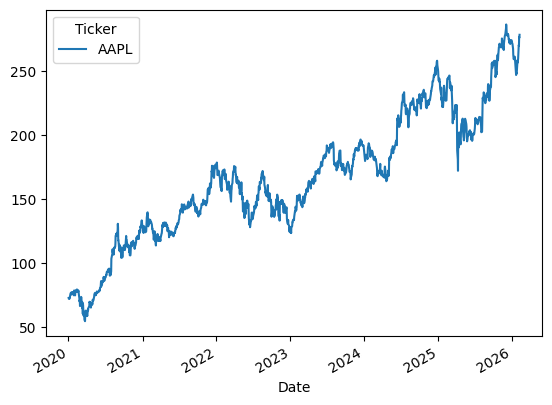

In [8]:
# print(df)
df.Close.plot() # Fetch the Close column and plot it -> Y Axis -> X axis is dates; Date is the index of the returned dataframe hence X Axis 

In [9]:
scaler = StandardScaler() # SciLearn
# Transform the Close column with SciLearn -> Scale it so that it fits the distribution
# Helps fit data into a specific range Could be mean 0 and variance +-1 -> And can further leads to smaller variation -> Leads to a tighter bound 
# It also enables the data to be equally weighted among other columns (Say Close Price of Apple $250 and 1M shares of volume bought can lead to prioritize volume more than the Close Price)
df['Close'] = scaler.fit_transform(df['Close']) 
# print(df)

In [11]:
seq_length = 30 # Dataspace to leverage for predicting the next set of days
data = [] # Data set for leveraging to predict data models

for i in range(len(df) - seq_length):
    data.append(df['Close'][i:i+seq_length])

data = np.array(data) # 3-D Array with last dimension just being distribution values

# We are fetching the first 80% of the data we are getting as our training data to predict and validate the last 20% (?)
train_size = int(0.8 * len(data)) # So we got sequences of 29 days of subarrays

# Convert the Training Data into PyTorch Tensor -> Convert it into N-D Array (Similar to numpy but can run on GPU and perform AutoDiff)
# Predict the 30th from first 29 AND also predict the last 20% from first 80%
# [first 80% of the data in the dataset, for every sequence array get everything but last element, and everything in the dimension of the first sequence values]
X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device) # 29 elements
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device) # 30th element

X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device) # Last 20% of the data first 29
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device) # Last element

In [195]:
# Our prediction model inheriting from the torch model 
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        # Recurrent Neural Networks (RNN) -> Long Short Term Memory -> Analyze Long term dependencies of sequential data 
        # Input_Dim - Each Time step amount of info [Close Price] - could give 4 if want to look at Close, Open, High, Low
        # Hidden_Dim - Number remember patterns -> Internal Values The LSTM learns it has leveraged
        # Num_Layers - 1 LSTM reads input - 2nd LSTM reads output
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim) # Layer for Linear neural network Layer -> feedforward/fullyConnected network -> Single layer of output (1)

    # LSTM - 2 Outputs - 1 h and 1 c output 
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device) # Hidden State Blank -> LSTM -> has h and c output -> Zeros arrays (Zero Tensors)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        # Pass everything through LSTM
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out


In [196]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [198]:
# Training Models
criterion = nn.MSELoss() # Evaluation
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 200 # Number of times the model sees the same datasets

for i in range(num_epochs):
    y_train_pred = model(X_train) # Training prediction on the model -> Make a prediction

    # We want to see how off we were in terms of predicting the 30th day
    # Y_Train_Pred - Leverages the first 29 days of the 80th percentile of data
    # Y_Train - 30th day of data we got from the 80%
    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i, loss.item())

    optimizer.zero_grad() # Model is passed to optimizer which is being trained
    loss.backward() # Back propogate the loss - i.e correction based on the loss
    optimizer.step() # Step forward 

0 0.6069865822792053
25 0.013726121746003628
50 0.005249216686934233
75 0.004731027875095606
100 0.00444147689267993
125 0.0042017013765871525
150 0.003980007953941822
175 0.0037745554000139236


In [199]:
# Visualization of unseen data
model.eval()

y_test_pred = model(X_test) # Last 20% of the data

y_train_pred  = scaler.inverse_transform(y_train_pred.detach().cpu().numpy()) # Inverse Scalar - Transform the data back to the original values of 0-1
y_train  = scaler.inverse_transform(y_train.detach().cpu().numpy()) # Inverse Scalar
y_test_pred  = scaler.inverse_transform(y_test_pred.detach().cpu().numpy()) # Inverse Scalar
y_test  = scaler.inverse_transform(y_test.detach().cpu().numpy()) # Inverse Scalar


In [200]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [201]:
train_rmse

3.0268445014953613

In [202]:
test_rmse

9.910564422607422

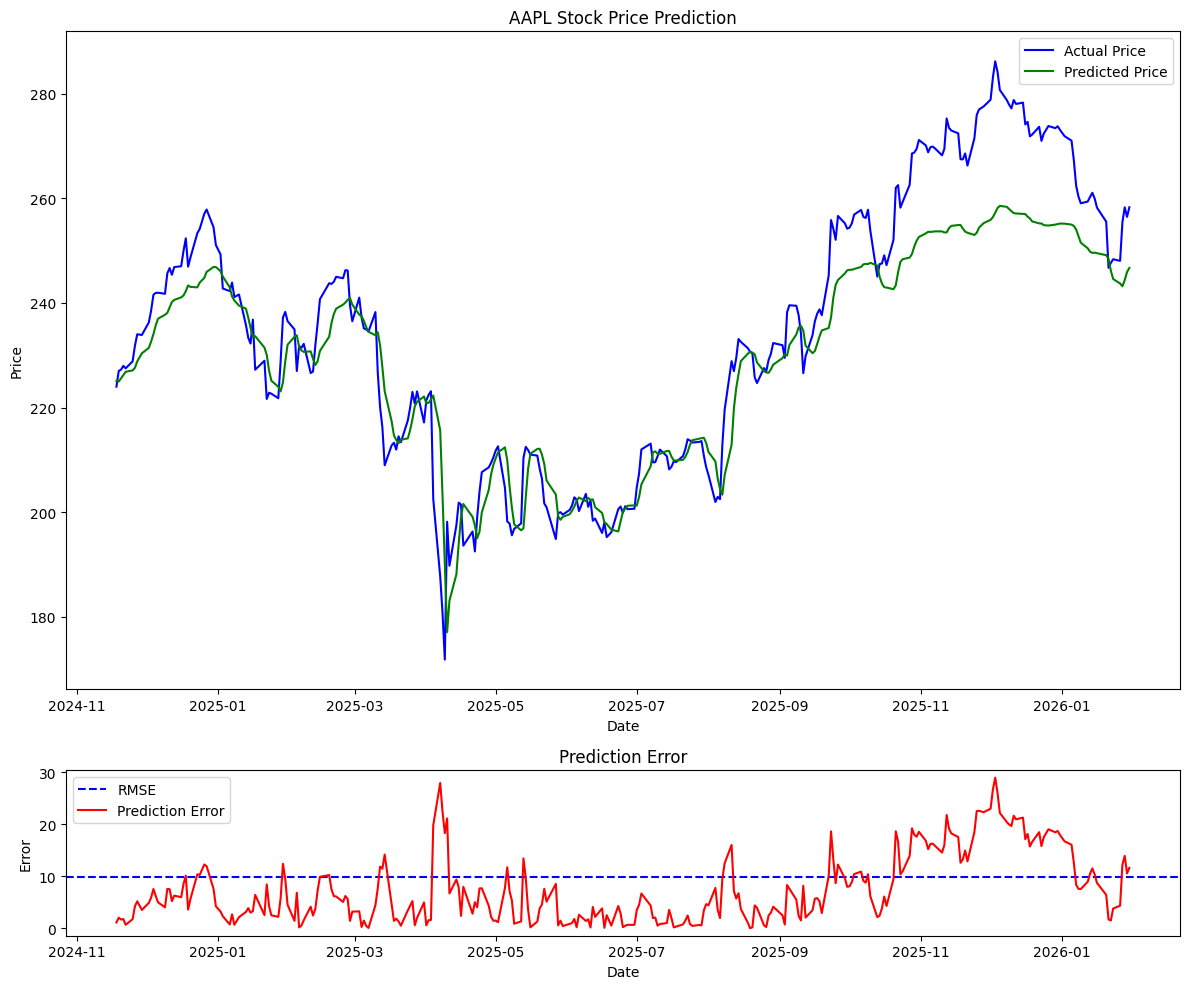

In [203]:
fig = plt.figure(figsize=(12,10))

gs = fig.add_gridspec(4,1)

ax1 = fig.add_subplot(gs[:3,0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = 'blue', linestyle='--', label = 'RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')

plt.tight_layout()
plt.show()

In [ ]:
# Figure Out the Prediction Model